# Лабораторная работа №4, вариант 8

### Цель работы: изучение принципов решения задачи многомерной регрессии с использованием методов машинного обучения. 

#### Вариант 8 – Жилье в Бостоне

Датасет –  boston.csv

Набор данных содержит информацию о жилье для различных районов Бостона. 


Этот набор данных содержит информацию, собранную Службой переписи населения США относительно жилья в районе Бостона, штат Массачусетс. Набор данных содержит 506 строк, каждая из которых представляет отдельный дом в этом районе. Имеется 14 столбцов, каждый из которых представляет отдельный аспект домов и их окрестностей.




Атрибуты: 


• crim – уровень преступности на душу населения по городам. 


• zn – доля жилой земли, отведенная под участки площадью более 25 000 кв. футов. 


• indus – доля акров неторговой коммерческой недвижимости в расчете на один город. 


• chas – фиктивная переменная реки Чарльз (1, если участок ограничивает реку; 0 в противном случае). 


• nox – концентрация оксидов азота (частей на 10 миллионов). 


• rm – среднее количество комнат в жилище. 


• age – доля единиц жилья, занимаемых владельцами, построенных до 1940 года.

 
• dis – взвешенные расстояния до пяти бостонских центров занятости. 


• rad – индекс доступности радиальных магистралей. 


• tax – полная ставка налога на имущество за 10 000 долларов США. 


• ptratio – соотношение учеников и учителей по городам. 


• b – рассчитывается как 1000 (Bk – 0,63)^2, где Bk — доля людей афроамериканского происхождения по городам. 


• lstat – процент более низкого статуса населения. 


• medv – медианная стоимость домов, занимаемых владельцами, в тысячах долларов США, которая часто является целевой переменной в задачах регрессии. 

**1. Импортируйте необходимые библиотеки и загружаем данные**

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('boston.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


**2. Получим информацию о датасете**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


**3. Проверяем наличие пропущенных значений и выбросов**

In [50]:
print(df.isnull().sum())

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64


Пропущенные значения отсутствуют, следовательно пропускаем пункт с заполнением пропусков.

**3. Исключаем невлияющие категориальные признаки**

В нашем случае нет необходимости удалять категориальные признаки, так как все признаки являются количественными.

**4. Разделяем данные на признаки и целевую перемнную**

In [54]:
df_copy = df.copy()

y = df_copy['medv']
X = df_copy.drop('medv', axis=1)

type(X), type(y)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

In [55]:
print("Целевая переменная (y):")
print(y.head())

print("\nПризнаки (X):")
print(X.head())

Целевая переменная (y):
0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: medv, dtype: float64

Признаки (X):
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

    black  lstat  
0  396.90   4.98  
1  396.90   9.14  
2  392.83   4.03  
3  394.63   2.94  
4  396.90   5.33  


**5. Разделяем данные на обучающую и тестовую выборку**

In [73]:
from sklearn.model_selection import train_test_split

#Данные разделены в соотношении 75/25 (25% - для тестирования)
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.25, random_state=0)

**6. Применяем операцию нормализации для численной устойчивости**

In [58]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

scaler = StandardScaler()
scaler

,copy,True
,with_mean,True
,with_std,True


**7. Масштабируем признаки обучающей выборки**

In [59]:
X_train_scaled = scaler.fit_transform(X_train)

scaler.mean_, scaler.scale_

(array([3.41273591e+00, 1.18614776e+01, 1.10835092e+01, 6.59630607e-02,
        5.56160422e-01, 6.31268338e+00, 6.87356201e+01, 3.78192876e+00,
        9.41160950e+00, 4.03226913e+02, 1.84897098e+01, 3.58808232e+02,
        1.25462797e+01]),
 array([8.24732271e+00, 2.37786892e+01, 7.01222710e+00, 2.48217516e-01,
        1.16025397e-01, 6.92476063e-01, 2.81774199e+01, 2.09216495e+00,
        8.66463849e+00, 1.71093414e+02, 2.18907691e+00, 8.90516961e+01,
        7.19324714e+00]))

**8. Обучаем модель линейной регресии**

In [60]:
model = LinearRegression().fit(X_train_scaled, y_train)
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**9. Делаем прогноз на основе данных тестирования**

In [62]:
# преобразуем тестовые данные с использованием среднего и СКО, рассчитанных на обучающей выборке
# так тестовые данные не повлияют на обучение модели, и мы избежим утечки данных
X_test_scaled = scaler.transform(X_test)

y_pred = model.predict(X_test_scaled)
y_pred[:5]

array([24.95233283, 23.61699724, 29.20588553, 11.96070515, 21.33362042])

In [63]:
from sklearn.metrics import root_mean_squared_error

# сравним тестовые и прогнозные значения
print('Root Mean Squared Error (RMSE):', root_mean_squared_error(y_test, y_pred))

Root Mean Squared Error (RMSE): 5.457311159564052


Root Mean Squared Error (RMSE) показывает среднюю величину ошибки предсказания в абсолютных единицах. 5.457 тысяч - это средняя ошибка модели при предсказании стоимости дома. 

In [64]:
from sklearn.metrics import r2_score
print('R2:', np.round(r2_score(y_test, y_pred), 2))

R2: 0.64


R2 (коэффициент детерминации) показывает, какая доля дисперсии целевой переменной объясняется моделью.


0.64 = 64% - модель объясняет 64% изменчивости цен на жилье. 36% изменчивости обусловлено факторами, не учтенными в модели.

In [65]:
model.score(X_test_scaled, y_test)

0.6354638433202132

**10. Итоговое уравнение**

![ИтоговоеУравнение](ИтоговоеУравнение.png)

In [66]:
print ('Coefficients: ', model.coef_)

Coefficients:  [-0.97100092  1.04667838 -0.04044753  0.59408776 -1.80876877  2.60991991
 -0.19823317 -3.00216551  2.08021582 -1.93289037 -2.15743759  0.75199122
 -3.59027047]


In [67]:
print ('Intercept: ', model.intercept_)

Intercept:  22.608707124010564


**11. Оценим влияние признаков на целевую переменную**

Пропускаем этап заполнения пропусков и изменения категориальных признаков на исходном датасете, потому что для нашего варианта это не требуется

In [70]:
df.corr()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


Сильнейшие положительные корреляции:


rm = 0.695 - среднее количество комнат в жилище

zn = 0.360 - доля большой жилой земли

black = 0.333 - демографический фактор

Сильнейшие отрицательные корреляции:


lstat = -0.738 - процент низкого статуса

ptratio = -0.508 - соотношение учеников/учителей

indus = -0.484 - промышленная недвижимость

**12.Визуализация результатов регресии**

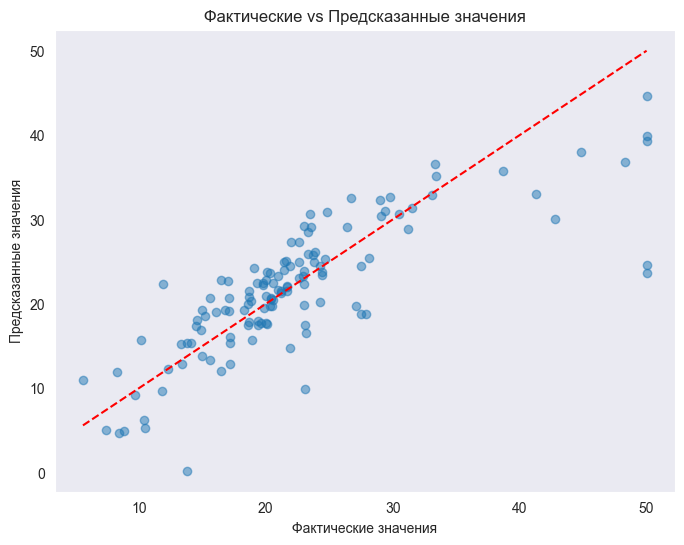

In [71]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Фактические значения")
plt.ylabel("Предсказанные значения")
plt.title("Фактические vs Предсказанные значения")
plt. grid()
plt.show()

 Модель в целом адекватно предсказывает стоимость жилья, особенно для среднего ценового сегмента от 15 до 35 тысяч долларов. Точки достаточно близко группируются вокруг диагональной линии, что подтверждает правильность направления модели. Однако наблюдается, что для дорогих домов модель склонна занижать предсказания, а для дешевых — завышать. Это указывает на наличие нелинейных зависимостей.

**13.Остатки регресии**

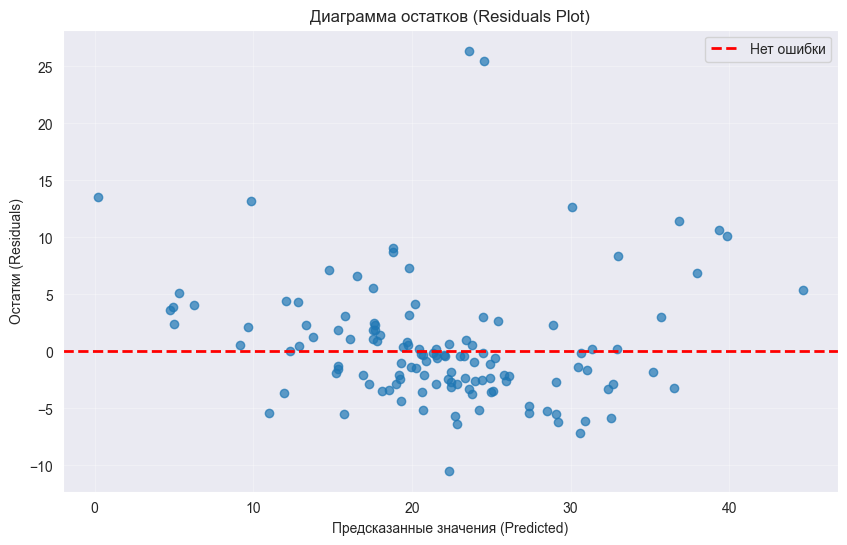

In [72]:
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Нет ошибки')
plt.xlabel('Предсказанные значения (Predicted)')
plt.ylabel('Остатки (Residuals)')
plt.title('Диаграмма остатков (Residuals Plot)')
plt. legend()
plt.grid(True, alpha=0.3)
plt.show()

Остатки в основном беспорядочно разбросаны вокруг горизонтальной нулевой линии, что является положительным признаком. Не наблюдается явных дуг, форм или конусов.

Модель объясняет около 64% изменений цен на жилье, что является хорошим результатом для линейного подхода. Она правильно определяет главные факторы цены. Модель адекватна для большинства случаев, но имеет склонность занижать прогнозы для дорогого жилья и завышать для дешевого.